# Analysis of the Association Between Variations in Obesity Prevalence Among Year 6 Children Across London Boroughs and Socioeconomic Factors

## Preparation

- [Github link](https://github.com/CHENYIZHAO1203/CASA006.git) *[Optional]*

- Number of words: 1493

- Runtime: 22 seconds (*Memory 32 GB, CPU AMD Ryzen AI 7 H 350 w/ Radeon 860M  (2.00 GHz)*)

- Coding environment: Podman (JupyterLab)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Childhood obesity is a public health issue of continuing concern in England, as it not only affects children's current and future health, but also reflects wider social and spatial inequalities. The National Child Measurement Programme has been monitoring children's weight for a long time. The latest official statistics show that the obesity rate among Year 6 children is relatively high in England, indicating that research on this issue at the local level is still of practical significance (NHS, 2024).

Some studies have generally pointed to a stable association between childhood obesity and socio-economic disadvantage. Kinra, Nelder, and Lewendon (2000) found in a UK urban study that children in poorer areas were more likely to be obese. Conrad and Capewell (2012) further show that there is a significant positive correlation between childhood overweight and obesity rates and area deprivation on a local scale in England. White, Rehkopf and Mortensen (2016) found that socioeconomic inequalities in childhood obesity did not decrease over a period. Broadbent et al., (2024) further suggest that this inequality is persistent. It can be seen that childhood obesity is not just an individual behavioral problem, but is also closely related to the local socio-economic environment.

Based on this, this essay uses the London ward as the unit of analysis to study the differences in the prevalence of obesity among sixth-grade children in different wards, and focuses on examining the relationship between several local socioeconomic variables and their changes.

## Research questions

[[ go back to the top ]](#Table-of-contents)

Which ward-level socio-economic factors are most strongly associated with differences in the prevalence of obesity among sixth-form children in London?

## Data

[[ go back to the top ]](#Table-of-contents)

This study uses the Greater London Authority (GLA) Ward Profiles dataset as the primary data source.During the data cleaning process, only observations at the ward level were retained, whilst summary rows and records with missing key variables were deleted; the final sample comprised 612 wards.The dependent variable was the prevalence of obesity among sixth-grade children, and the median household income, employment rate, proportion of the population without formal education, and proportion of dependent children in unemployed households were selected as explanatory variables.

In [1]:
# =========================
# Load, clean, and prepare the data
# =========================
import pandas as pd
import numpy as np

# 1. Read raw data
url = "https://raw.githubusercontent.com/CHENYIZHAO1203/CASA006/main/Data/ward-profiles-excel-version.csv"
df = pd.read_csv(url, encoding="latin1", low_memory=False)
# if read data local
## df = pd.read_csv("Data/ward-profiles-excel-version.csv", encoding="latin1", low_memory=False)

# 2. Retain only ward level (New code starts with E05)
df_ward = df[df["New code"].astype(str).str.startswith("E05")].copy()

# 3. Select the variables 
cols = [
    "Ward name",
    "New code",
    "% children in year 6 who are obese- 2011/12 to 2013/14",
    "Median Household income estimate (2012/13)",
    "Employment rate (16-64) - 2011",
    "% with no qualifications - 2011",
    "% dependent children (0-18) in out-of-work households - 2014",
    "Claimant rate of key out-of-work benefits (working age client group) (2014)",
    "Claimant Rate of Housing Benefit (2015)",
    "% of lone parents not in employment - 2011",
    "Rate of JobSeekers Allowance (JSA) Claimants - 2015"
]

df_ward = df_ward[cols].copy()

# 4. Rename the variable to facilitate subsequent analysis
df_ward = df_ward.rename(columns={
    "Ward name": "ward_name",
    "New code": "ward_code",
    "% children in year 6 who are obese- 2011/12 to 2013/14": "year6_obesity_pct",
    "Median Household income estimate (2012/13)": "median_income",
    "Employment rate (16-64) - 2011": "employment_rate",
    "% with no qualifications - 2011": "no_qual_pct",
    "% dependent children (0-18) in out-of-work households - 2014": "child_workless_pct",
    "Claimant rate of key out-of-work benefits (working age client group) (2014)": "outofwork_benefit_rate",
    "Claimant Rate of Housing Benefit (2015)": "housing_benefit_rate",
    "% of lone parents not in employment - 2011": "loneparent_noemp_pct",
    "Rate of JobSeekers Allowance (JSA) Claimants - 2015": "jsa_rate"
})

# 5. Remove observations with missing values for the dependent variable
df_ward = df_ward.dropna(subset=["year6_obesity_pct"]).copy()

# 6. Review of basic data
print("Dataset shape:", df_ward.shape)
print("\nMissing values:")
print(df_ward.isna().sum())

Dataset shape: (612, 11)

Missing values:
ward_name                 0
ward_code                 0
year6_obesity_pct         0
median_income             0
employment_rate           0
no_qual_pct               0
child_workless_pct        0
outofwork_benefit_rate    0
housing_benefit_rate      0
loneparent_noemp_pct      0
jsa_rate                  0
dtype: int64


In [2]:
# Look at the previous lines to check the cleaned data
display(df_ward.head())

,ward_name,ward_code,year6_obesity_pct,median_income,employment_rate,no_qual_pct,child_workless_pct,outofwork_benefit_rate,housing_benefit_rate,loneparent_noemp_pct,jsa_rate
1,Barking and Dagenham - Abbey,E05000026,24.7,33920.0,60.3,16.4,22.1,15.1,16.1,55.3,4.0
2,Barking and Dagenham - Alibon,E05000027,26.0,32470.0,63.1,31.2,24.7,20.7,17.7,61.0,3.7
3,Barking and Dagenham - Becontree,E05000028,29.3,33000.0,61.2,28.0,22.0,17.8,16.4,51.5,3.6
4,Barking and Dagenham - Chadwell Heath,E05000029,24.6,33920.0,63.6,29.1,24.3,19.4,15.1,55.2,3.7
5,Barking and Dagenham - Eastbrook,E05000030,21.6,37400.0,68.2,29.9,20.4,14.7,12.1,48.7,4.0


In addition, for the purposes of spatial visualisation, this paper utilises boundary data for London wards to create a choropleth map illustrating the spatial distribution of obesity prevalence among Year 6 pupils.

In [3]:
# =========================
# Read ward shapefile 
# =========================
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Read the ward shapefile
wards_gdf = gpd.read_file(
    "https://raw.githubusercontent.com/CHENYIZHAO1203/CASA006/main/Data/London_Ward_CityMerged.geojson"
)
# if read data local
## wards_gdf = gpd.read_file("Data/statistical-gis-boundaries-london/ESRI/London_Ward_CityMerged.shp")

# 2. Checking column names
print(wards_gdf.columns.tolist())
display(wards_gdf.head())

# 3. Rename join key
wards_gdf = wards_gdf.rename(columns={"GSS_CODE": "ward_code"})

# 4. Merging Attribute Data
map_gdf = wards_gdf.merge(
    df_ward,
    on="ward_code",
    how="left"
)

print("Map dataframe shape:", map_gdf.shape)
print("Missing obesity values after join:", map_gdf["year6_obesity_pct"].isna().sum())


['NAME', 'GSS_CODE', 'HECTARES', 'NONLD_AREA', 'LB_GSS_CD', 'BOROUGH', 'POLY_ID', 'geometry']


,NAME,GSS_CODE,HECTARES,NONLD_AREA,LB_GSS_CD,BOROUGH,POLY_ID,geometry
0,Chessington South,E05000405,755.173,0.0,E09000021,Kingston upon Thames,50840,"POLYGON ((-0.33066 51.32901, -0.33057 51.32909..."
1,Tolworth and Hook Rise,E05000414,259.464,0.0,E09000021,Kingston upon Thames,117160,"POLYGON ((-0.30843 51.37586, -0.30832 51.37606..."
2,Berrylands,E05000401,145.390,0.0,E09000021,Kingston upon Thames,50449,"POLYGON ((-0.30383 51.39249, -0.30373 51.39252..."
3,Alexandra,E05000400,268.506,0.0,E09000021,Kingston upon Thames,50456,"POLYGON ((-0.26988 51.38845, -0.26973 51.38838..."
4,Beverley,E05000402,187.821,0.0,E09000021,Kingston upon Thames,117161,"POLYGON ((-0.2466 51.39921, -0.2467 51.3992, -..."


Map dataframe shape: (625, 18)
Missing obesity values after join: 13


The main six variables showed below：

| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| year6_obesity_pct                 | Numeric      | Percentage of Year 6 children classified as obese in each ward  |   |
| median_income                         | Numeric      | Median household income in each ward                                                 |   |
| employment_rate  | Numeric  | Employment rate of the working-age population                                    |   |
| no_qual_pct  | Numeric  | Percentage of residents with no formal qualifications                                    |   |
| child_workless_pct                 | Numeric      | Percentage of dependent children in out-of-work households.  |   |
| ward_code                 | Categorical      | Unique ward code used to merge attribute data with spatial boundaries  |   |

## Methodology

[[ go back to the top ]](#Table-of-contents)


Source: see [github link](https://github.com/CHENYIZHAO1203/CASA006/blob/main/methodology.png).

![methodology](https://raw.githubusercontent.com/CHENYIZHAO1203/CASA006/main/methodology.png)

This essay uses ward-level cross-sectional ecological analyses. The goal of the study is to identify the socioeconomic characteristics that underlie differences in childhood obesity prevalence between wards, and therefore this paper discusses associations at the area level rather than causality at the individual level.

The analysis consisted of four steps. 1. Using descriptive statistics, distribution plots, scatter plots, correlation heatmaps, and graded color maps, a preliminary description of the prevalence of childhood obesity and its spatial variations was conducted. 2. Lasso regression model is constructed as a sparse linear benchmark for testing the main variables in a linear framework. 3. Construct a Random Forest regression model to capture potential nonlinear relationships and interactions between variables. 4. Interpret the tree model using permutation importance and partial dependence plots to identify the most important variables and observe the patterns of relationships between key variables and the predicted outcomes.

Model evaluation uses a training and test set split, with 5-fold cross-validation performed on the training set. Model performance is compared using RMSE, MAE, and R².

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [4]:
# Generate the main analysis variable table
main_vars = [
    "year6_obesity_pct",
    "median_income",
    "employment_rate",
    "no_qual_pct",
    "child_workless_pct"
]

desc_table = df_ward[main_vars].describe().T
desc_table = desc_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

print("\nTable 1: Descriptive statistics for main variables:")
display(desc_table)


Table 1: Descriptive statistics for main variables:


,count,mean,std,min,25%,50%,75%,max
year6_obesity_pct,612.0,21.75,5.15,5.9,18.58,22.7,25.32,35.0
median_income,612.0,38781.70,6634.95,25090.0,33562.50,38080.0,43130.00,65500.0
employment_rate,612.0,69.45,6.48,46.1,64.90,70.2,74.30,83.9
no_qual_pct,612.0,17.87,5.86,4.5,13.78,17.6,21.62,35.8
child_workless_pct,612.0,15.91,7.37,2.2,9.70,15.9,21.52,35.5


Table 1 shows that the prevalence of obesity among Year 6 children across 612 London wards averaged 21.75%, ranging from 5.9% to 35.0%, indicating significant variation between wards.The core socioeconomic variables also exhibit strong spatial heterogeneity, for example, median household income ranges from £25,090 to £65,500, and the proportion of dependent children in unemployed households ranges from 2.2% to 35.5%.

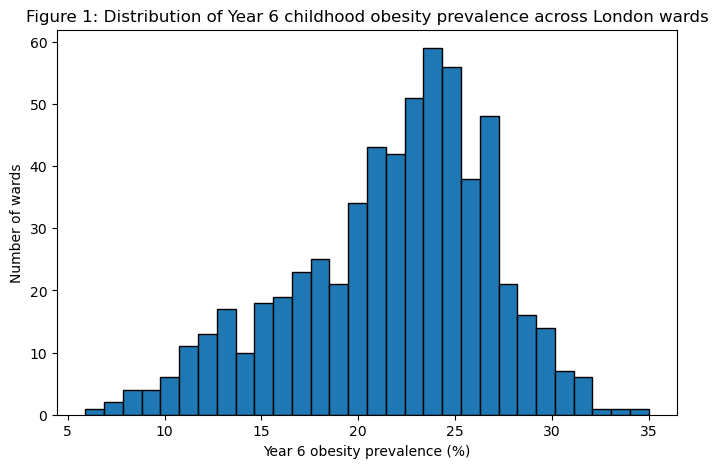

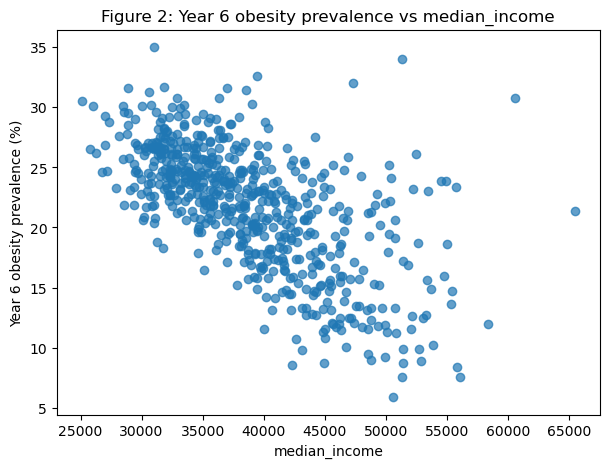

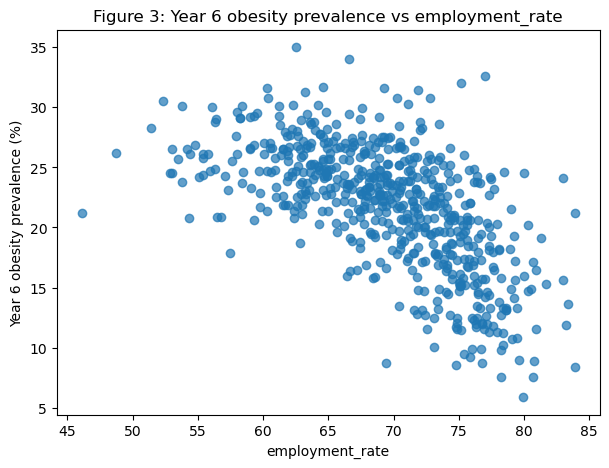

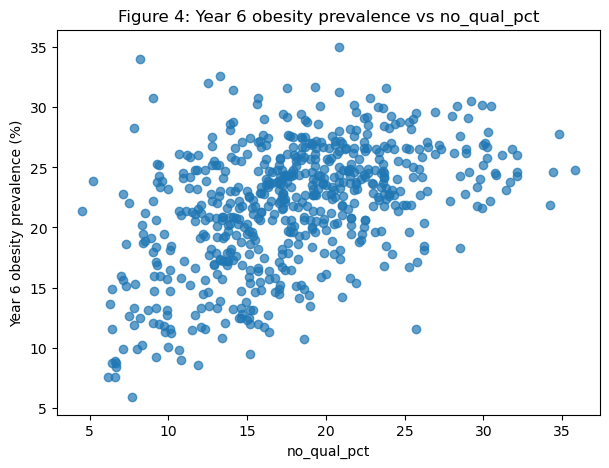

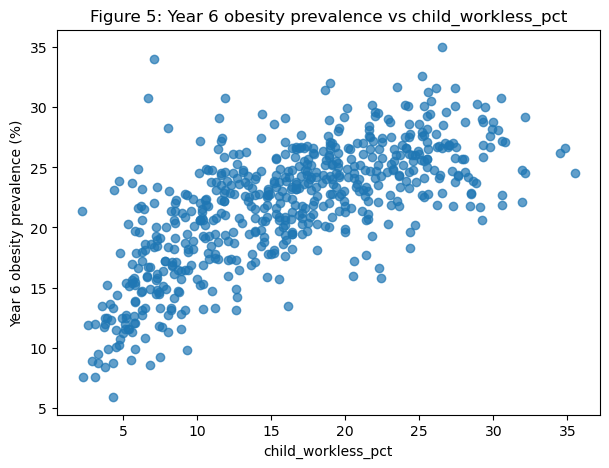

Table 2: Correlation with Year 6 obesity prevalence:


,year6_obesity_pct
year6_obesity_pct,1.000
median_income,-0.637
employment_rate,-0.618
no_qual_pct,0.478
child_workless_pct,0.700


In [5]:
# =========================
# Distribution of the outcome + bivariate scatter plots
# =========================

import matplotlib.pyplot as plt

# 1. Distribution plot of the dependent variable
plt.figure(figsize=(8, 5))
plt.hist(df_ward["year6_obesity_pct"].dropna(), bins=30, edgecolor="black")
plt.xlabel("Year 6 obesity prevalence (%)")
plt.ylabel("Number of wards")
plt.title("Figure 1: Distribution of Year 6 childhood obesity prevalence across London wards")
plt.show()

# 2. Scatter plot of the four core independent variables and the dependent variable
core_predictors = [
    "median_income",
    "employment_rate",
    "no_qual_pct",
    "child_workless_pct"
]

## for var in core_predictors:
for i, var in enumerate(core_predictors, 2):
    temp = df_ward[[var, "year6_obesity_pct"]].dropna()
    
    plt.figure(figsize=(7, 5))
    plt.scatter(temp[var], temp["year6_obesity_pct"], alpha=0.7)
    plt.xlabel(var)
    plt.ylabel("Year 6 obesity prevalence (%)")
    plt.title(f"Figure {i}: Year 6 obesity prevalence vs {var}")
    plt.show()

# 3. Table of Correlation Coefficients
corr_table = df_ward[["year6_obesity_pct"] + core_predictors].corr()[["year6_obesity_pct"]]
corr_table = corr_table.round(3)

print("Table 2: Correlation with Year 6 obesity prevalence:")
display(corr_table)

Figure 1 shows that the prevalence of obesity among children in Year 6 is predominantly centred around 20 per cent, although there are a small number of very low and high wards at either end of the scale, suggesting that the indicator is not homogenous within London.

The scatter plots in Figures 2 to 5 further show that the prevalence of childhood obesity is negatively correlated with median household income and employment rate, with correlation coefficients of -0.637 and -0.618, respectively; and positively correlated with the proportion of the population without formal education and the proportion of dependent children in unemployed households, with correlation coefficients of 0.478 and 0.700, respectively. Among these, child_workless_pct has the strongest correlation, suggesting that household work poverty may be the most critical explanatory factor.

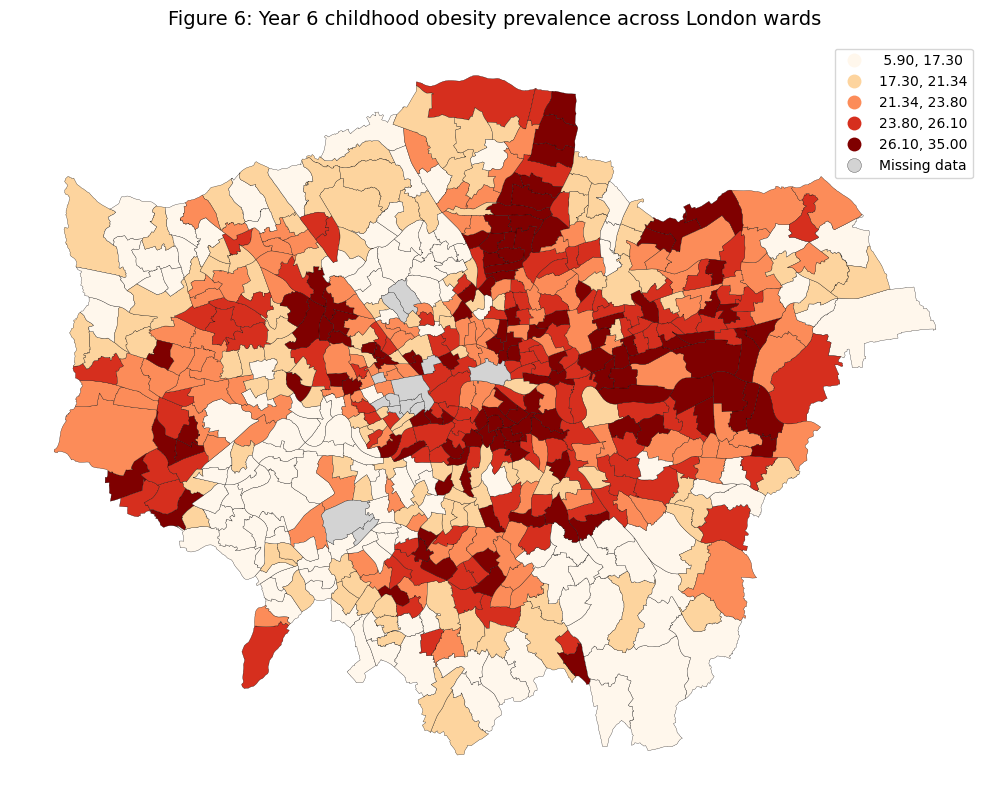

In [6]:
# =========================
#  choropleth map
# =========================
fig, ax = plt.subplots(figsize=(10, 10))

map_gdf.plot(
    column="year6_obesity_pct",
    scheme="Quantiles",   
    k=5,                  
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing data"
    },
    ax=ax
)

ax.set_title("Figure 6: Year 6 childhood obesity prevalence across London wards", fontsize=14, pad=12)
ax.axis("off")

plt.tight_layout()
plt.show()

The choropleth map in Figure 6 further shows that the high values of childhood obesity ward are not randomly distributed, but are concentrated in areas with relatively weak socio-economic conditions, showing obvious spatial clustering characteristics. This result is largely consistent with the previous statistical analysis and further illustrates the close link between childhood obesity and socioeconomic inequality within London.

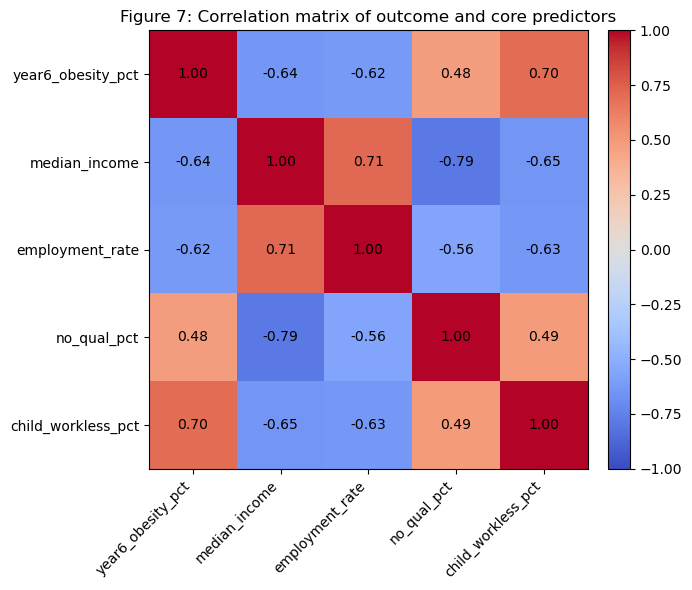

X_train shape: (489, 4)
X_test shape: (123, 4)

Table 3: LassoCV performance:


,Metric,Train,Test
0,RMSE,3.437,3.329
1,MAE,2.689,2.547
2,R2,0.530,0.647


Best alpha selected by LassoCV: 0.0735

Table 4: Lasso coefficients:


,variable,coefficient
3,child_workless_pct,2.1508
0,median_income,-0.9876
1,employment_rate,-0.8850
2,no_qual_pct,-0.0000


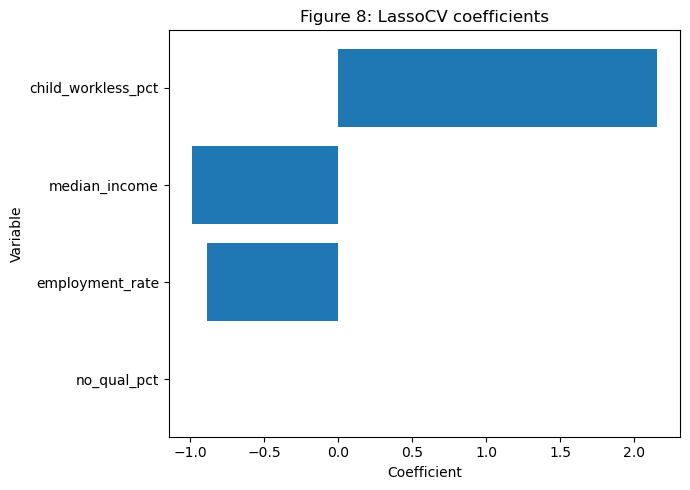

In [7]:
# =========================
# Correlation heatmap + train/test split + LassoCV
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Correlation heatmap
heatmap_vars = [
    "year6_obesity_pct",
    "median_income",
    "employment_rate",
    "no_qual_pct",
    "child_workless_pct"
]

corr_matrix = df_ward[heatmap_vars].corr()

plt.figure(figsize=(7, 6))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(heatmap_vars)), heatmap_vars, rotation=45, ha="right")
plt.yticks(range(len(heatmap_vars)), heatmap_vars)
plt.title("Figure 7: Correlation matrix of outcome and core predictors")

# Write the correlation coefficient in the grid
for i in range(len(heatmap_vars)):
    for j in range(len(heatmap_vars)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=10
        )

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 2. Preparing modeling data
predictors = [
    "median_income",
    "employment_rate",
    "no_qual_pct",
    "child_workless_pct"
]

X = df_ward[predictors].copy()
y = df_ward["year6_obesity_pct"].copy()

# 3. Divide the training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 4. Create LassoCV pipeline
lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42, max_iter=10000))
])

# 5. Train Models
lasso_model.fit(X_train, y_train)

# 6. Anticipate
y_train_pred = lasso_model.predict(X_train)
y_test_pred = lasso_model.predict(X_test)

# 7. Assessment of indicators
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

lasso_train_mae = mean_absolute_error(y_train, y_train_pred)
lasso_test_mae = mean_absolute_error(y_test, y_test_pred)

lasso_train_r2 = r2_score(y_train, y_train_pred)
lasso_test_r2 = r2_score(y_test, y_test_pred)

lasso_results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "Train": [lasso_train_rmse, lasso_train_mae, lasso_train_r2],
    "Test": [lasso_test_rmse, lasso_test_mae, lasso_test_r2]
}).round(3)

print("\nTable 3: LassoCV performance:")
display(lasso_results)

# 8. Extract factor
lasso_estimator = lasso_model.named_steps["lasso"]

lasso_coef = pd.DataFrame({
    "variable": predictors,
    "coefficient": lasso_estimator.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

print("Best alpha selected by LassoCV:", round(lasso_estimator.alpha_, 5))
print("\nTable 4: Lasso coefficients:")
display(lasso_coef.round(4))

# 9. Coefficient visualisation
plt.figure(figsize=(7, 5))
plt.barh(lasso_coef["variable"], lasso_coef["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Figure 8: LassoCV coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Figure 6 is consistent with these results and also suggests that there is some overlap between some of the explanatory variables.

Table 3 shows that LassoCV has an RMSE of 3.329, a MAE of 2.547, and an R² of 0.647 on the test set.Figure 8 shows that child_workless_pct has the most pronounced positive effect, median_income and employment_rate are negative, and no_qual_pct is compressed to 0, indicating a weak independent linear contribution.

Best RF parameters:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 500}

Table 5: Random Forest performance:


,Metric,Train,Test
0,RMSE,2.480,3.036
1,MAE,1.979,2.294
2,R2,0.755,0.707



Table 6: Model comparison on the test set:


,Model,Test_RMSE,Test_MAE,Test_R2
0,LassoCV,3.329,2.547,0.647
1,Random Forest,3.036,2.294,0.707


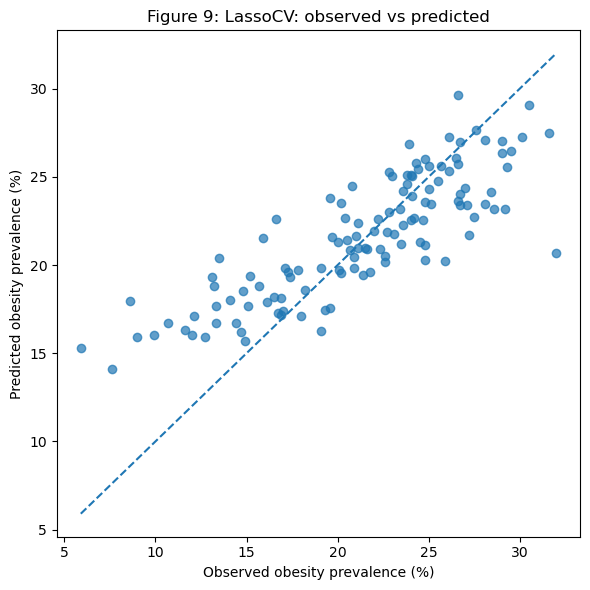

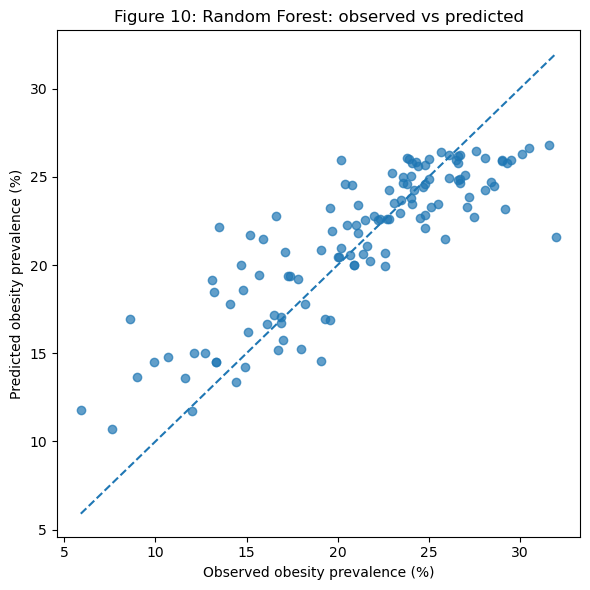

In [8]:
# =========================
# Random Forest regressor + model comparison
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Create Random Forest pipeline
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(random_state=42))
])

# 2. Setting the parameter grid
param_grid = {
    "rf__n_estimators": [200, 500],
    "rf__max_depth": [None, 5, 10, 15],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

# 3. Tuning with 5-fold CV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF parameters:")
print(rf_grid.best_params_)

# 4. Fetch the best model
rf_best = rf_grid.best_estimator_

# 5. Anticipate
y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

# 6. Assessment of indicators
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

rf_results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "Train": [rf_train_rmse, rf_train_mae, rf_train_r2],
    "Test": [rf_test_rmse, rf_test_mae, rf_test_r2]
}).round(3)

print("\nTable 5: Random Forest performance:")
display(rf_results)

# 7. Model Comparison Table
comparison_table = pd.DataFrame({
    "Model": ["LassoCV", "Random Forest"],
    "Test_RMSE": [lasso_test_rmse, rf_test_rmse],
    "Test_MAE": [lasso_test_mae, rf_test_mae],
    "Test_R2": [lasso_test_r2, rf_test_r2]
}).round(3)

print("\nTable 6: Model comparison on the test set:")
display(comparison_table)

# 8. Predicted value vs. true value plots (Lasso)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Observed obesity prevalence (%)")
plt.ylabel("Predicted obesity prevalence (%)")
plt.title("Figure 9: LassoCV: observed vs predicted")
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
plt.show()

# 9. Predicted value vs. true value plots (Lasso)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.7)
plt.xlabel("Observed obesity prevalence (%)")
plt.ylabel("Predicted obesity prevalence (%)")
plt.title("Figure 10: Random Forest: observed vs predicted")
min_val = min(y_test.min(), y_test_pred_rf.min())
max_val = max(y_test.max(), y_test_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
plt.show()

Random Forest outperforms Lasso, with a test set RMSE of 3.036, MAE of 2.294, and R² of 0.707, suggesting that the relationship between socio-economic conditions and childhood obesity is not completely linear, and that the tree model is better able to capture more complex relationships. Figure9-10 show the comparison between the actual and predicted values also shows that Random Forest performs better overall than the linear model.

Table 7: Permutation importance (Random Forest, test set):


,variable,importance_mean,importance_std
3,child_workless_pct,2.1691,0.2166
0,median_income,0.9402,0.1217
1,employment_rate,0.7645,0.1434
2,no_qual_pct,0.0564,0.0238


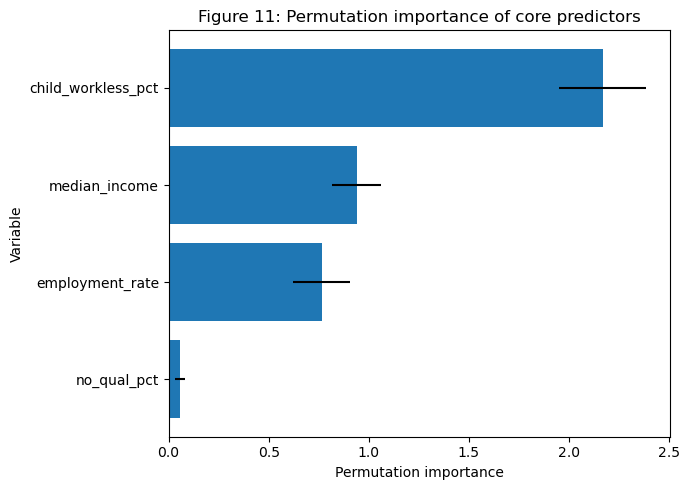

In [9]:
# =========================
# Permutation importance for the Random Forest model
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

# 1. Calculate permutation importance on the test set
perm_result = permutation_importance(
    estimator=rf_best,
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

# 2. Collation results table
perm_importance_df = pd.DataFrame({
    "variable": predictors,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("Table 7: Permutation importance (Random Forest, test set):")
display(perm_importance_df.round(4))

# 3. Drawing variable importance diagrams
plt.figure(figsize=(7, 5))
plt.barh(
    perm_importance_df["variable"],
    perm_importance_df["importance_mean"],
    xerr=perm_importance_df["importance_std"]
)
plt.xlabel("Permutation importance")
plt.ylabel("Variable")
plt.title("Figure 11: Permutation importance of core predictors")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The permutation importance results in Table 7 and Figure 11 show that child_workless_pct is the most important explanatory variable, followed by median_income and employment_rate, while no_qual_pct has a relatively limited contribution.

Top 2 features for PDP: ['child_workless_pct', 'median_income']


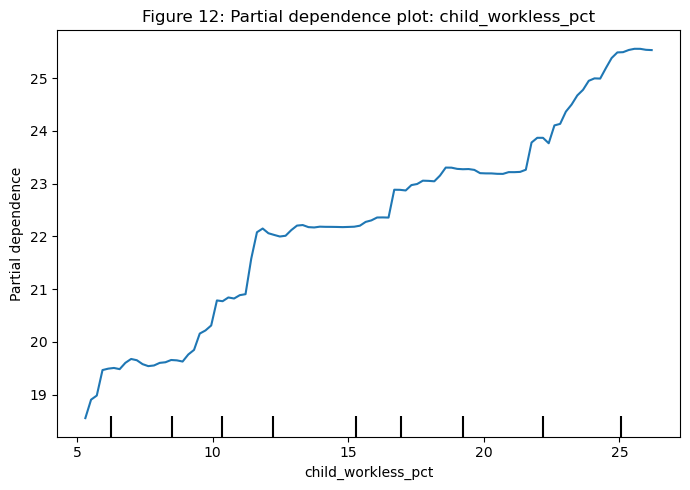

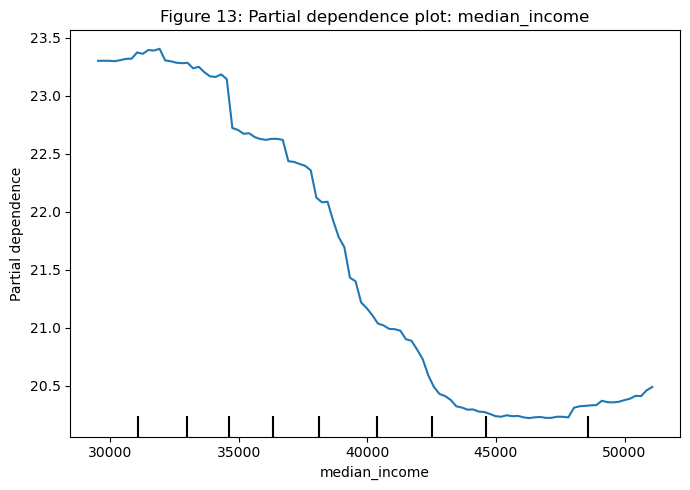

In [10]:
# =========================
# Partial Dependence Plots for the top 2 most important variables
# =========================

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 1. The top 2 variables with the highest permutation importance were selected.
top2_features = perm_importance_df["variable"].head(2).tolist()
print("Top 2 features for PDP:", top2_features)

# 2. Draw PDP
for i, feature in enumerate(top2_features, 12):
    fig, ax = plt.subplots(figsize=(7, 5))
    PartialDependenceDisplay.from_estimator(
        estimator=rf_best,
        X=X_test,
        features=[feature],
        ax=ax
    )
    ax.set_title(f"Figure {i}: Partial dependence plot: {feature}")
    plt.tight_layout()
    plt.show()

Partial dependence plots in Figure12-13 also support this conclusion: as child_workless_pct rises, the predicted prevalence of childhood obesity increases overall; as median_income rises, the predicted values decrease overall.This indicates that family working poverty and economic resource level are the two dimensions most closely related to differences in childhood obesity.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

Using London ward as the unit of analysis, this eassy examines which local level socio-economic factors are most strongly associated with differences in the prevalence of obesity in Year 6 children. The results showed that there were significant differences in the prevalence of childhood obesity among different wards in London, and that these differences were closely related to socioeconomic conditions.The proportion of dependent children in unemployed households, median household income, and employment rates all show strong significance, whether in correlation analyses, Lasso regressions, or Random Forest models.

The model comparison results further show that Random Forest outperforms Lasso, indicating that the relationship between socioeconomic factors and childhood obesity is not entirely linear.However, there is an overall consistency in the identification of key variables between the two types of models, which enhances the robustness of the results. As can be seen from the spatial distribution map, the high values of childhood obesity are not randomly distributed, but are more concentrated in areas with relatively weak socioeconomic conditions.

This study also has some limitations.This essay uses ward-level aggregated data, so the conclusions can only explain statistical associations at the district level. Secondly, this paper uses a cross-sectional design, which makes it impossible to make rigorous causal inferences. Nonetheless, this paper suggests that the problem of childhood obesity in London is closely linked to local socio-economic inequalities, and that policies may need to pay more attention to family working poverty and regional resource imbalances if they are to be more effective in reducing levels of childhood obesity.

## References

[[ go back to the top ]](#Table-of-contents)

Broadbent, P., Shen, Y., Pearce, A. and Katikireddi, S. V. (2024). ‘Trends in inequalities in childhood overweight and obesity prevalence: a repeat cross-sectional analysis of the Health Survey for England’. BMJ Publishing Group Ltd. 

Conrad, D. and Capewell, S. (2012). ‘Associations between deprivation and rates of childhood overweight and obesity in England, 2007–2010: an ecological study’. British Medical Journal Publishing Group.

Kinra, S., Nelder, R. P. and Lewendon, G. J. (2000). ‘Deprivation and childhood obesity: a cross sectional study of 20 973 children in Plymouth, United Kingdom’. Journal of Epidemiology & Community Health. BMJ Publishing Group Ltd, 54 (6), pp. 456–460. 

National Child Measurement Programme, England, 2023/24 School Year. (no date). NHS England Digital. Available at: [here](https://digital.nhs.uk/data-and-information/publications/statistical/national-child-measurement-programme/2023-24-school-year).

White, J., Rehkopf, D. and Mortensen, L. H. (2016). ‘Trends in Socioeconomic Inequalities in Body Mass Index, Underweight and Obesity among English Children, 2007–2008 to 2011–2012’. PLOS ONE. Public Library of Science, 11 (1), p. e0147614. 